In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src/')

In [2]:
import utils
import importlib
importlib.reload(utils)

<module 'utils' from '/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Notebooks/../src/utils.py'>

In [3]:
h = 0.67 

Om_m = 0.315            # matter density
Om_b = 0.022/(h*h)      # baryonic matter density
Om_lambda = 0.685       # vacuum energy density

rho_c = 2.78e11 *h*h    # in units of M_s/Mpc^3

# mean matter density of the universe
rho_0 = Om_m * rho_c    # in units of M_s/Mpc^3
delta_c = 1.686         # Critical density for spherical collapse

# for normalising the power spectrum
sigma8_obs = 0.811      # Observed value of sigma_8
n = 0.965               # power spectrum P(k)~ k^n

z_range = np.linspace(0.1,20, 100)

from numba import jit

f_b = Om_b/Om_m     # fraction of baryonic matter
H0 = h/9.78e9         # in units of 1/yr

#  Accretion Shocks

## Relativistic Electron Energy Density

In [4]:
def E_bb(M, z): #Baryon binding energy of a halo of mass M (in SM) at redshift z in erg
    Om_m_z = Om_m * (1 + z) ** 3 / (Om_m * (1 + z) ** 3 + Om_lambda)
    d = Om_m_z - 1
    delta_c = 18 * np.pi ** 2 + 82 * d - 39 * d ** 2
    baryon_frac = Om_b / Om_m #Need only baryon binding energy
    return 5.45 * 10 ** (53) * (M * h / 10 ** 8) ** (5 / 3) * (Om_m / Om_m_z * delta_c / (18 * np.pi ** 2)) ** (1 / 3) * (1 + z) / (10 * h) * baryon_frac

In [5]:
min_T_vir = 10 ** 4 #Efficient atomic cooling above this temp

neutral_mu = 1.23
k_B_SI = 1.38 * 10 ** (-23) #m^2 kg s^-2 K^-1
m_p_kg = 1.67 * 10 ** (-27) #kg

min_V_c = np.sqrt(min_T_vir * 2 * (k_B_SI / (1000) ** 2) / (neutral_mu * m_p_kg))

def M_factor(z): #The coefficient of M^1/3 in V_c formula
    Om_m_z = Om_m * (1 + z) ** 3 / (Om_m * (1 + z) ** 3 + Om_lambda)
    d = Om_m_z - 1
    delta_c = 18 * np.pi ** 2 + 82 * d - 39 * d ** 2
    return 23.4 * (Om_m / Om_m_z * delta_c / (18 * np.pi ** 2)) ** (1 / 6) * ((1 + z) / 10) ** (1 / 2) / (10 ** 8 * h ** (-1)) ** (1 / 3)

def M_crit(z):
    return (min_V_c / M_factor(z)) ** (3)

In [6]:
M_range = np.logspace(6, 16, 500)  # Mass range in solar masses

M_arrs_inz = [] #Mass range set by V_c critical

for i in range(len(z_range)):
    arr = np.logspace(np.log10(M_crit(z_range[i])), 16, 500)
    M_arrs_inz.append(arr)

M_arrs_inz = np.array(M_arrs_inz)

In [7]:
from utils import PS_MassFunc

In [8]:
dn_dlogM_new = np.zeros((len(M_range), len(z_range)))
integrand_rel_en_dens = np.zeros((len(M_range), len(z_range)))

f_r = 0.1 #fraction of binding energy going into relativistic electrons

for i in range(len(z_range)):
    for j in range(len(M_range)):
        dn_dlogM_new[j, i] = PS_MassFunc(M_arrs_inz[i][j], z_range[i]) * (rho_0 / M_arrs_inz[i][j])
        integrand_rel_en_dens[j, i] = dn_dlogM_new[j, i] * f_r * E_bb(M_arrs_inz[i][j], z_range[i])

In [9]:
Rel_energy_dens = np.trapezoid(integrand_rel_en_dens, x=np.log10(M_range), axis=0)

Text(0.5, 1.0, 'Relativistic Electron Energy Density')

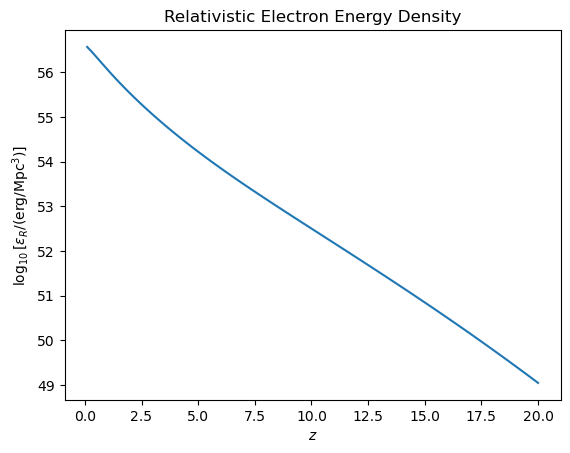

In [10]:
plt.plot(z_range, np.log10(Rel_energy_dens))
plt.ylabel(r'$\log_{10}[\epsilon_R/(\text{erg/Mpc}^{3})]$')
plt.xlabel(r'$z$')
plt.title(r'Relativistic Electron Energy Density')

## Thermal Background Energy Density

In [11]:
def n_gas(z): #Gas density as a function of redshift
    neutral_mu = 1.23
    m_p = 1.67 * 10 ** (-27) * (5.03 * 10 ** (-31)) #Solar mass
    rho_b0 = Om_b * rho_c
    n_0 = rho_b0 / (neutral_mu * m_p)
    return n_0

In [12]:
n_arr = np.zeros_like(z_range)

for i in range(len(z_range)):
    n_arr[i] = n_gas(z_range[i])

Text(0, 0.5, '$n_\\text{gas}(z)$ (Mpc$^{-3}$)')

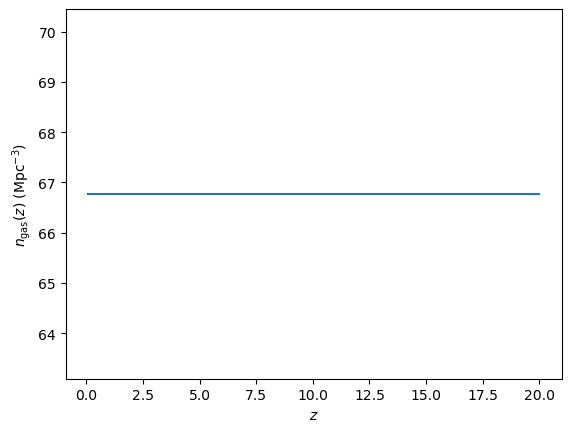

In [13]:
plt.plot(z_range, np.log10(n_arr))
plt.xlabel(r'$z$')
plt.ylabel(r'$n_\text{gas}(z)$ (Mpc$^{-3}$)')

In [14]:
def E_thermal_dens(z, T): #Inputing z and T arr we have already calculated
    k_B = 1.38 * 10 ** (-16) #in CGS
    neutral_mu = 1.23
    m_p = 1.67 * 10 ** (-27) * (5.03 * 10 ** (-31)) #Solar mass
    rho_b0 = Om_b * rho_c
    n_0 = rho_b0 / (neutral_mu * m_p)
    T_arr = np.zeros_like(z)
    for i in range(len(z)):
        T_arr[i] = 3 / 2 * n_0 * k_B * T
    return T_arr

In [15]:
Thermal_energy_dens1 = E_thermal_dens(z_range, 10)
Thermal_energy_dens2 = E_thermal_dens(z_range, 100)
Thermal_energy_dens3 = E_thermal_dens(z_range, 10**4)

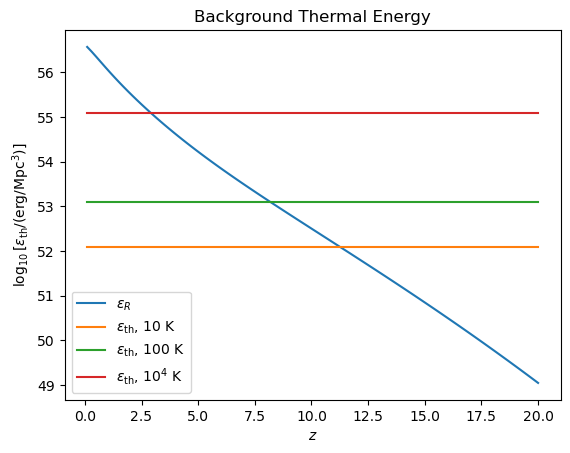

In [16]:
plt.plot(z_range, np.log10(Rel_energy_dens), label = r'$\epsilon_R$')
plt.plot(z_range, np.log10(Thermal_energy_dens1), label = r'$\epsilon_\text{th}$, 10 K')
plt.plot(z_range, np.log10(Thermal_energy_dens2), label = r'$\epsilon_\text{th}$, 100 K')
plt.plot(z_range, np.log10(Thermal_energy_dens3), label = r'$\epsilon_\text{th}$, $10^4$ K')
plt.xlabel(r'$z$')
plt.ylabel(r'$\log_{10}[\epsilon_\text{th}/(\text{erg/Mpc}^3)]$')
plt.title(r'Background Thermal Energy')
plt.legend()

In [17]:
Energy_dens_ratio1 = Rel_energy_dens / Thermal_energy_dens1
Energy_dens_ratio2 = Rel_energy_dens / Thermal_energy_dens2
Energy_dens_ratio3 = Rel_energy_dens / Thermal_energy_dens3

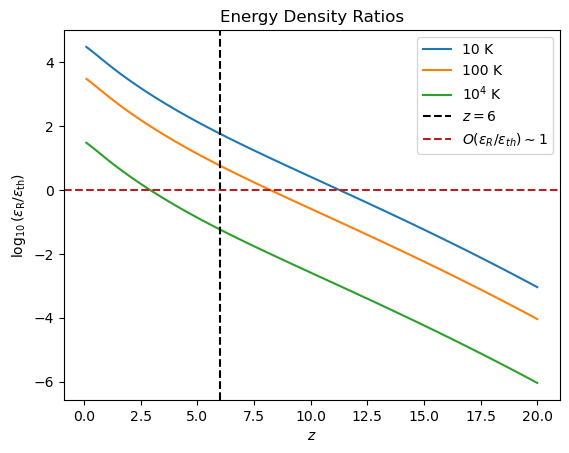

In [18]:
plt.plot(z_range, np.log10(Energy_dens_ratio1), label = r'10 K')
plt.plot(z_range, np.log10(Energy_dens_ratio2), label = r'100 K')
plt.plot(z_range, np.log10(Energy_dens_ratio3), label = r'$10^4$ K')
plt.xlabel(r'$z$')
plt.ylabel(r'$\log_{10}(\epsilon_\text{R}/\epsilon_\text{th})$')
plt.title(r'Energy Density Ratios')
plt.axvline(6, ls = '--', color = r'black', label = r'$z=6$')
plt.axhline(0, ls = '--', color = r'firebrick', label = r'$O(\epsilon_R/\epsilon_{th})\sim1$')
plt.legend()

In [19]:
crossings = np.where(np.diff(np.sign(Energy_dens_ratio3 - 1)))[0]

z_cross = z_range[crossings[0]]
print(z_cross)

2.713131313131313


# Emissivity Comparizon Plot

## HMXBS

In [20]:
from utils import Madau

In [21]:
SFRD_vals = np.zeros_like(z_range)
HMXB_Em_vals = np.zeros_like(z_range)

L_HMXB = 10 ** (40)

for i in range(len(z_range)):
    SFRD_vals[i] = Madau(z_range[i])
    HMXB_Em_vals[i] = L_HMXB * SFRD_vals[i]

## LMXBs

In [22]:
def H(z): #in km/s/Mpc
    return 67 * np.sqrt( Om_m*(1+z)**3 + Om_lambda )

Mpctokm = 3.086 * 10 ** (19)
SectoYr = 1 / (3.154 * 10 ** 7)

def dt_dz(z): #In yr
    return -1 / ((1 + z) * H(z) / (SectoYr * Mpctokm))

In [23]:
def LM_Int(z):
    return Madau(z) * np.abs(dt_dz(z))

In [24]:
LM_Int_vals = np.zeros_like(z_range)

for i in range(len(z_range)):
    LM_Int_vals[i] = LM_Int(z_range[i])

In [25]:
Madau_vals = Madau(z_range)

In [26]:
from scipy.integrate import cumulative_trapezoid

In [27]:
z = z_range                # ascending: 0 → 20
f = LM_Int(z)

# cumulative integral from 0 → z
cum_int = cumulative_trapezoid(f, z, initial=0)

# total integral from 0 → 20
total = cum_int[-1]

# desired: integral from z → 20
F = total - cum_int

In [28]:
L_LMXB = 10 ** (30.5)

Ret_fact = 0.39

LMXB_Em_vals = L_LMXB * F * (1 - Ret_fact)

## Accretion Shocks

In [29]:
Yrtosec = 3.154 * 10 ** 7
Mpctokm = 3.086 * 10 ** (19)

def Time_ff(z):
    return 1 / np.sqrt(27 * np.pi ** 2 * (H(z) / Mpctokm) ** 2)

In [30]:
Time_ff(0)

np.float64(2.8215604830375628e+16)

In [31]:
Time_ff_vals = Time_ff(z_range)

AccShocks_Em_vals = Rel_energy_dens / Time_ff_vals

/tmp/ipykernel_5966/179818335.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.plot(z_range, np.log10(LMXB_Em_vals), label = r'LMXB')


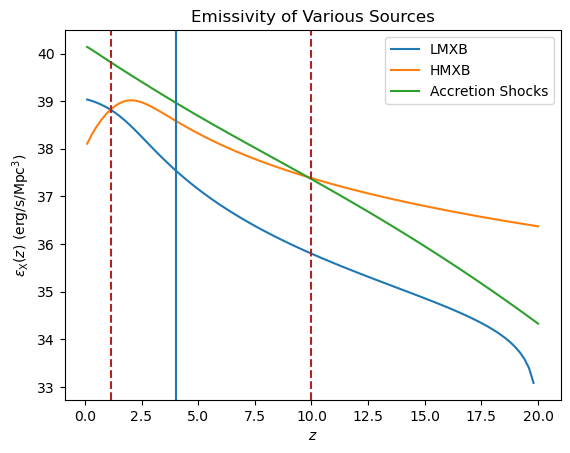

In [32]:
plt.plot(z_range, np.log10(LMXB_Em_vals), label = r'LMXB')
plt.plot(z_range, np.log10(HMXB_Em_vals), label = r'HMXB')
plt.plot(z_range, np.log10(AccShocks_Em_vals), label = r'Accretion Shocks')

plt.xlabel(r'$z$')
plt.ylabel(r'$\epsilon_\text{X}(z)$ (erg/s/Mpc$^3$)')
plt.title(r'Emissivity of Various Sources')
plt.legend()
plt.axvline(10, ls = '--', color = r'firebrick')
plt.axvline(1.15, ls = '--', color = r'firebrick')
plt.axvline(4)

## Accretion Shocks Spectrum Calculation

In [138]:
def accretion_emissivityPerEnergy(E, z): #Unnormalized accretion emissivity per unit energy
    return E ** (-1) / (1 + z) ** 3

In [139]:
gamma_min = 10 ** 2 #Least upscattering gamma
gamma_max = 10 ** 3 #Highest upscattering gamma

def Initial_CMB_energy(z): #CMB photon energy before upscattering event
    T_0 = 2.725 #K
    k_B = 1.38 * 10 ** (-16) #erg/K
    E_mean_0 = 2.701 * k_B * T_0 #Mean CMB energy today in erg
    return E_mean_0 * (1 + z)

z_in = 6 #Upscattering redshift

Initial_CMB_energy_val = Initial_CMB_energy(z_in)

def Upscattered_Energy(Initial_Energy, Gamma_val): #CMB photon energy after IC Upscattering
    return 4 / 3 * Gamma_val ** 2 * Initial_Energy

E_min = Upscattered_Energy(Initial_CMB_energy_val, gamma_min) #Upscattered energy corresponding to gamma_min
E_max = Upscattered_Energy(Initial_CMB_energy_val, gamma_max) #Upscattered energy corresponding to gamma_max

In [140]:
E_integration_range = np.linspace(E_min, E_max, 1000) #Defining integration range from E_min to E_max

#Integrating over the integration range
EmPerEn_integral = np.array([
    np.trapezoid(accretion_emissivityPerEnergy(E_integration_range, z),
                 x=E_integration_range)
    for z in z_range
])

Text(0.5, 1.0, 'Unnormalized Emissivity per Energy at $z=0$')

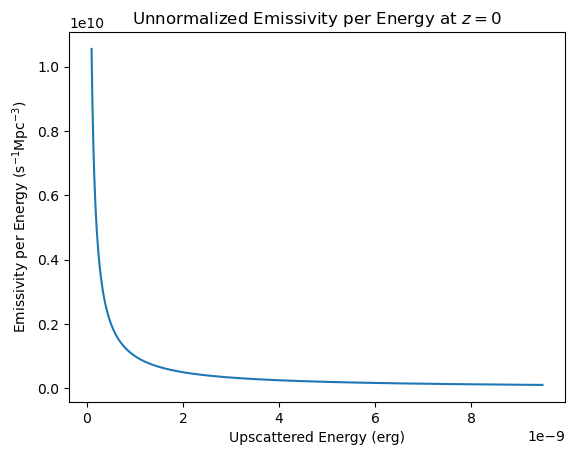

In [141]:
#Plotting the integrand at redshift 0
plt.plot(E_integration_range, accretion_emissivityPerEnergy(E_integration_range, 0))
plt.xlabel(r'Upscattered Energy (erg)')
plt.ylabel(r'Emissivity per Energy (s$^{-1}$Mpc$^{-3}$)')
plt.title(r'Unnormalized Emissivity per Energy at $z=0$')

Text(0.5, 1.0, 'Unnormalized Bolometric Emissivity vs Redshift')

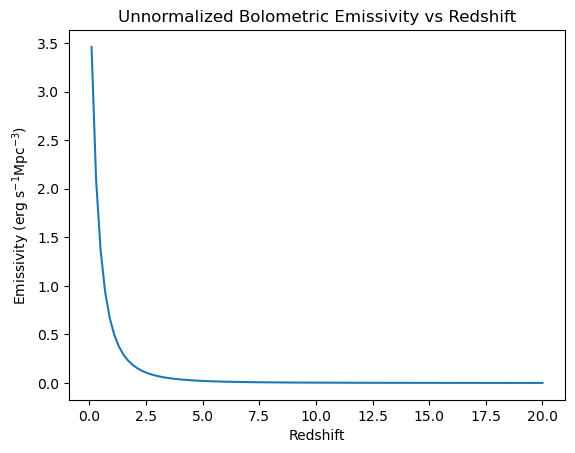

In [142]:
#Plotting the integral as a function of redshift
plt.plot(z_range, EmPerEn_integral)
plt.xlabel(r'Redshift')
plt.ylabel(r'Emissivity (erg s$^{-1}$Mpc$^{-3}$)')
plt.title(r'Unnormalized Bolometric Emissivity vs Redshift')

In [143]:
EmmPerEn_Norm = AccShocks_Em_vals / EmPerEn_integral #Finding the normalization of the emissivity per unit energy

In [144]:
Norm_EmPerEn_integral = EmmPerEn_Norm * EmPerEn_integral #Testing the normalized bolometric emissivity

Text(0.5, 1.0, 'Normalized Bolometric Emissivity vs Redshift')

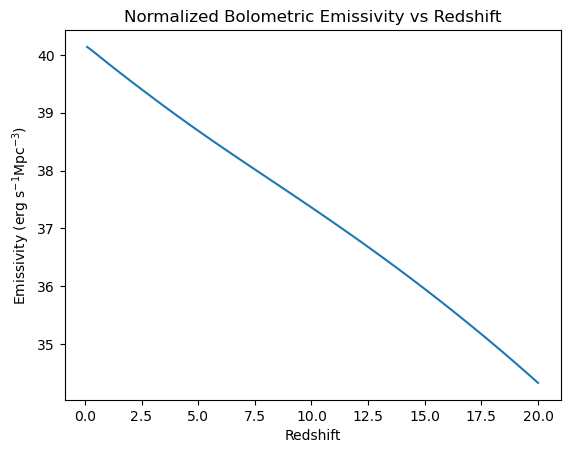

In [145]:
plt.plot(z_range, np.log10(Norm_EmPerEn_integral))
plt.xlabel(r'Redshift')
plt.ylabel(r'Emissivity (erg s$^{-1}$Mpc$^{-3}$)')
plt.title(r'Normalized Bolometric Emissivity vs Redshift')

In [41]:
Norm_EmPerEn_vals = np.zeros((len(z_range), len(E_integration_range)))

for i in range(len(z_range)):
    for j in range(len(E_integration_range)):
        Norm_EmPerEn_vals[i, j] = accretion_emissivityPerEnergy(E_integration_range[j], z_range[i]) * EmmPerEn_Norm[i]

ErgtokeV = 6.242 * 10 ** 8
E_int_range_keV = E_integration_range * ErgtokeV

In [42]:
z_range[30]

np.float64(6.13030303030303)

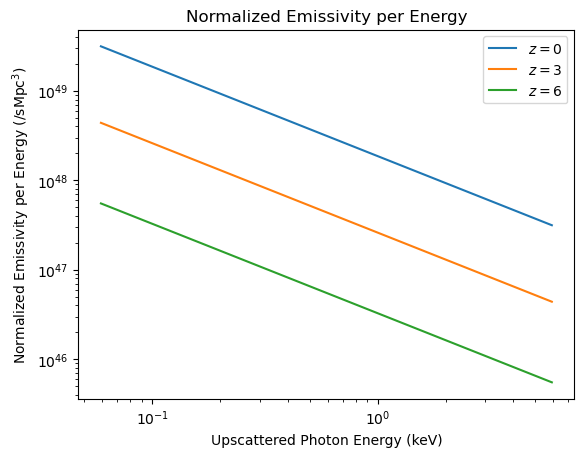

In [43]:
plt.loglog(E_int_range_keV, Norm_EmPerEn_vals[0], label = r'$z=0$')
plt.loglog(E_int_range_keV, Norm_EmPerEn_vals[14], label = r'$z=3$')
plt.loglog(E_int_range_keV, Norm_EmPerEn_vals[30], label = r'$z=6$')
plt.xlabel(r'Upscattered Photon Energy (keV)')
plt.ylabel(r'Normalized Emissivity per Energy (/sMpc$^3$)')
plt.title(r'Normalized Emissivity per Energy')
plt.legend()

## Quasi-Stellar Objects (QSOs)

In [48]:
def QSO_EmPerNu0(z): # Here Nu0 = c / 1000 A, as given by Khaire and Srianand
    return 4.53 * 10 ** 24 * (1 + z) ** 5.9 * np.e ** (-0.36 * z) / (np.e ** (2.2 * z) + 25.1)

def QSO_Bol_Em(z): # Fit from Khaire and Srianand
    wavelength = 1000 * 10 ** (-10) # in m
    sp_light = 3 * 10 ** 8 # in m/s
    freq = sp_light / wavelength # in hz
    return QSO_EmPerNu0(z) * freq

In [45]:
QSO_Bol_Em_vals = QSO_Bol_Em(z_range)

/tmp/ipykernel_5966/3267042244.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.plot(z_range, np.log10(LMXB_Em_vals), label = r'LMXB')


Text(0.5, 1.0, 'Bolometric Emissivity vs Redshift')

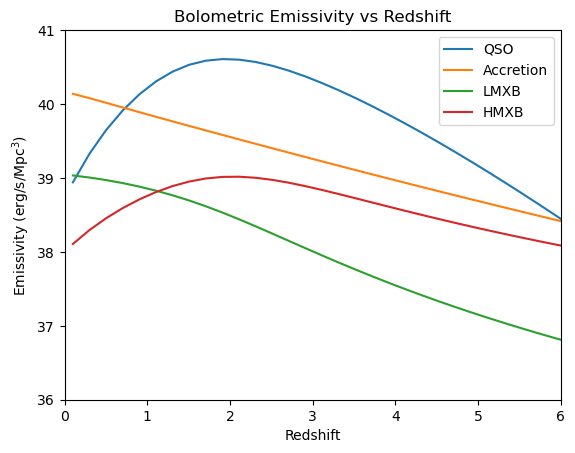

In [113]:
plt.plot(z_range, np.log10(QSO_Bol_Em_vals), label = r'QSO')
plt.plot(z_range, np.log10(Norm_EmPerEn_integral), label = r'Accretion')
plt.plot(z_range, np.log10(LMXB_Em_vals), label = r'LMXB')
plt.plot(z_range, np.log10(HMXB_Em_vals), label = r'HMXB')
plt.ylim(36, 41)
plt.xlim(0, 6)
plt.legend()

plt.xlabel(r'Redshift')
plt.ylabel(r'Emissivity (erg/s/Mpc$^3$)')
plt.title(r'Bolometric Emissivity vs Redshift')

In [64]:
def k_nu_Q1(E): # E in eV, k_nu is dimensionless
    A_1 = 2 ** (0.8)
    A_2 = 1
    h_nu_a = 2 * 10 ** 3# in eV, fiducial model adopted
    alpha = -1.8 # Power-law index of k_nu, corresponding to the fiducial model
    A_3 = np.e ** (-12.4 / h_nu_a)
    A_4 = A_3 * np.e ** (1 + h_nu_a / (2 * 10 ** 6)) * (h_nu_a / 12.4) ** alpha
    if E <= 6.2:
        return A_1 * (E / 6.2) ** (-0.5)
    elif E <= 12.4:
        return A_2 * (E / 12.4) ** (-0.8)
    elif E <= h_nu_a:
        return A_3 * (E / 12.4) ** (alpha) * np.e ** (E / h_nu_a)
    else:
        return A_4 * (E / h_nu_a) ** (-0.8) * np.e ** (-E / (2 * 10 ** 6))

In [65]:
def QSO_EmPerNu(E, z): # in erg/s/hz/Mpc^3
    return k_nu_Q1(E) * QSO_EmPerNu0(z)

Planck_Const = 6.626 * 10 ** (-27) # in erg s

def QSO_EmPerE(E, z): # in /s Mpc^3
    return QSO_EmPerNu(E, z) / Planck_Const

In [75]:
Test_nu_range = E_int_range_keV / (Planck_Const * ErgtokeV)

QSO_EmPerNu_arr = np.zeros((len(z_range), len(E_int_range_keV)))
Nu_QSO_EmPerNu_arr = np.zeros((len(z_range), len(E_int_range_keV)))

for i in range(len(z_range)):
    for j in range(len(E_int_range_keV)):
        QSO_EmPerNu_arr[i, j] = QSO_EmPerNu(E_int_range_keV[j] * 1000, z_range[i])
        Nu_QSO_EmPerNu_arr[i, j] = QSO_EmPerNu_arr[i, j] * Test_nu_range[j]

Text(0.5, 1.0, '$\\nu\\epsilon_\\nu$ vs $E$ at $z=0$')

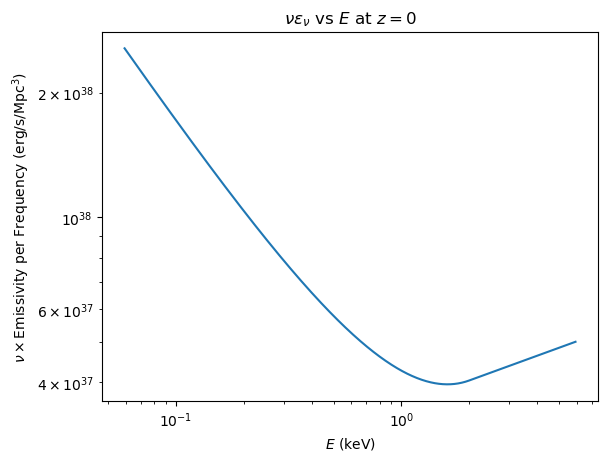

In [79]:
plt.loglog(E_int_range_keV, Nu_QSO_EmPerNu_arr[0])
plt.xlabel(r'$E$ (keV)')
plt.ylabel(r'$\nu\times$Emissivity per Frequency (erg/s/Mpc$^3$)')
plt.title(r'$\nu\epsilon_\nu$ vs $E$ at $z=0$')

In [66]:
QSO_EmPerE_arr = np.zeros((len(z_range), len(E_int_range_keV)))

for i in range(len(z_range)):
    for j in range(len(E_int_range_keV)):
        QSO_EmPerE_arr[i, j] = QSO_EmPerE(E_int_range_keV[j] * 1000, z_range[i])

Text(0.5, 1.0, 'Emissivity per Energy at $z=6$')

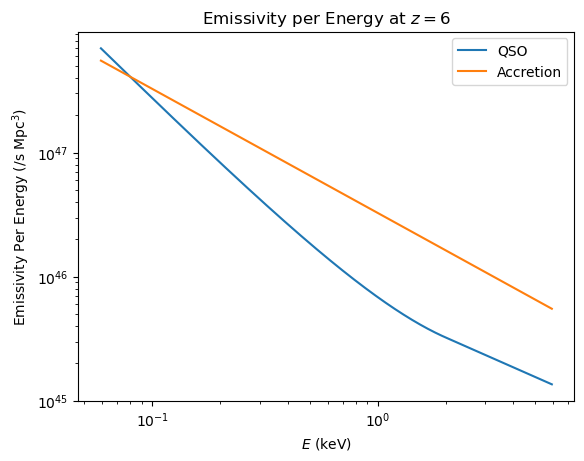

In [86]:
plt.loglog(E_int_range_keV, QSO_EmPerE_arr[30], label = r'QSO')
plt.loglog(E_int_range_keV, Norm_EmPerEn_vals[30], label = r'Accretion')
plt.xlabel(r'$E$ (keV)')
plt.ylabel(r'Emissivity Per Energy (/s Mpc$^3$)')
plt.legend()
plt.title(r'Emissivity per Energy at $z=6$')

In [84]:
z_range[35]

np.float64(7.135353535353534)

Text(0.5, 1.0, 'Emissivity per Energy at $z=7.1$')

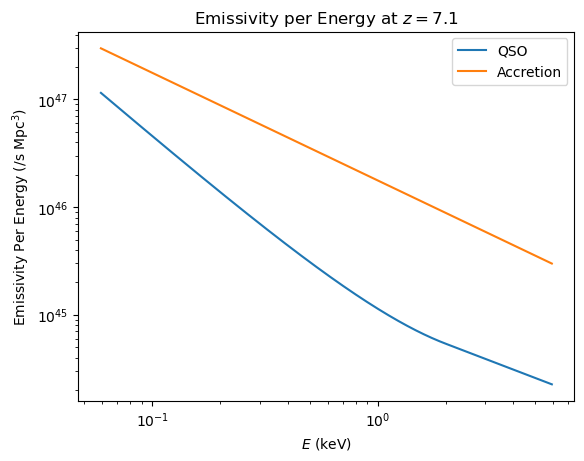

In [88]:
plt.loglog(E_int_range_keV, QSO_EmPerE_arr[35], label = r'QSO')
plt.loglog(E_int_range_keV, Norm_EmPerEn_vals[35], label = r'Accretion')
plt.xlabel(r'$E$ (keV)')
plt.ylabel(r'Emissivity Per Energy (/s Mpc$^3$)')
plt.legend()
plt.title(r'Emissivity per Energy at $z=7.1$')

## Varying $f_\text{R}$

In [89]:
f_r_2 = 0.05
f_r_3 = 0.01

dn_dlogM_new_2 = np.zeros((len(M_range), len(z_range)))
integrand_rel_en_dens_2 = np.zeros((len(M_range), len(z_range)))

for i in range(len(z_range)):
    for j in range(len(M_range)):
        dn_dlogM_new_2[j, i] = PS_MassFunc(M_arrs_inz[i][j], z_range[i]) * (rho_0 / M_arrs_inz[i][j])
        integrand_rel_en_dens_2[j, i] = dn_dlogM_new_2[j, i] * f_r_2 * E_bb(M_arrs_inz[i][j], z_range[i])

dn_dlogM_new_3 = np.zeros((len(M_range), len(z_range)))
integrand_rel_en_dens_3 = np.zeros((len(M_range), len(z_range)))

for i in range(len(z_range)):
    for j in range(len(M_range)):
        dn_dlogM_new_3[j, i] = PS_MassFunc(M_arrs_inz[i][j], z_range[i]) * (rho_0 / M_arrs_inz[i][j])
        integrand_rel_en_dens_3[j, i] = dn_dlogM_new_3[j, i] * f_r_3 * E_bb(M_arrs_inz[i][j], z_range[i])

In [91]:
Rel_energy_dens_2 = np.trapezoid(integrand_rel_en_dens_2, x=np.log10(M_range), axis=0)
Rel_energy_dens_3 = np.trapezoid(integrand_rel_en_dens_3, x=np.log10(M_range), axis=0)

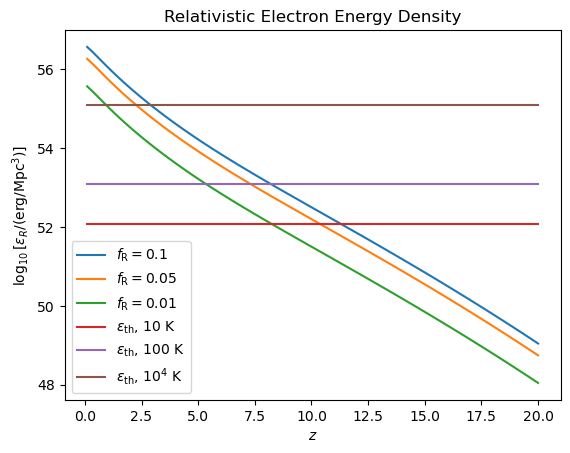

In [93]:
plt.plot(z_range, np.log10(Rel_energy_dens), label = r'$f_\text{R}=0.1$')
plt.plot(z_range, np.log10(Rel_energy_dens_2), label = r'$f_\text{R}=0.05$')
plt.plot(z_range, np.log10(Rel_energy_dens_3), label = r'$f_\text{R}=0.01$')
plt.ylabel(r'$\log_{10}[\epsilon_R/(\text{erg/Mpc}^{3})]$')
plt.xlabel(r'$z$')
plt.title(r'Relativistic Electron Energy Density')

plt.plot(z_range, np.log10(Thermal_energy_dens1), label = r'$\epsilon_\text{th}$, 10 K')
plt.plot(z_range, np.log10(Thermal_energy_dens2), label = r'$\epsilon_\text{th}$, 100 K')
plt.plot(z_range, np.log10(Thermal_energy_dens3), label = r'$\epsilon_\text{th}$, $10^4$ K')

plt.legend()

In [94]:
AccShocks_Em_vals_2 = Rel_energy_dens_2 / Time_ff_vals
AccShocks_Em_vals_3 = Rel_energy_dens_3 / Time_ff_vals

/tmp/ipykernel_5966/3214769952.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.plot(z_range, np.log10(LMXB_Em_vals), label = r'LMXB', ls = '--')


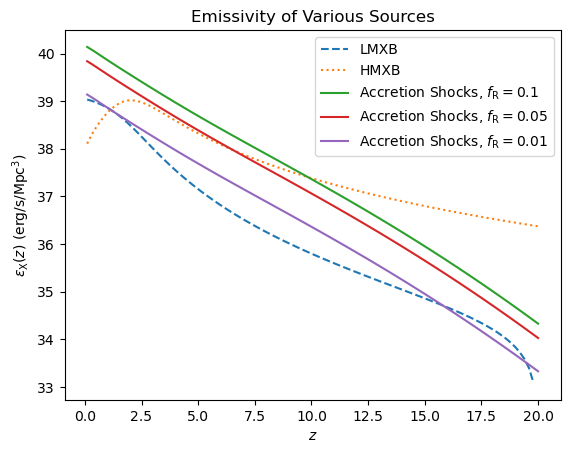

In [100]:
plt.plot(z_range, np.log10(LMXB_Em_vals), label = r'LMXB', ls = '--')
plt.plot(z_range, np.log10(HMXB_Em_vals), label = r'HMXB', ls = ':')
plt.plot(z_range, np.log10(AccShocks_Em_vals), label = r'Accretion Shocks, $f_\text{R}=0.1$')
plt.plot(z_range, np.log10(AccShocks_Em_vals_2), label = r'Accretion Shocks, $f_\text{R}=0.05$')
plt.plot(z_range, np.log10(AccShocks_Em_vals_3), label = r'Accretion Shocks, $f_\text{R}=0.01$')

plt.xlabel(r'$z$')
plt.ylabel(r'$\epsilon_\text{X}(z)$ (erg/s/Mpc$^3$)')
plt.title(r'Emissivity of Various Sources')
plt.legend()
#plt.axvline(10, ls = '--', color = r'firebrick')
#plt.axvline(1.15, ls = '--', color = r'firebrick')
#plt.axvline(4)

In [101]:
EmmPerEn_Norm_2 = AccShocks_Em_vals_2 / EmPerEn_integral #Finding the normalization of the emissivity per unit energy
EmmPerEn_Norm_3 = AccShocks_Em_vals_3 / EmPerEn_integral #Finding the normalization of the emissivity per unit energy

In [102]:
Norm_EmPerEn_integral_2 = EmmPerEn_Norm_2 * EmPerEn_integral #Testing the normalized bolometric emissivity
Norm_EmPerEn_integral_3 = EmmPerEn_Norm_3 * EmPerEn_integral #Testing the normalized bolometric emissivity

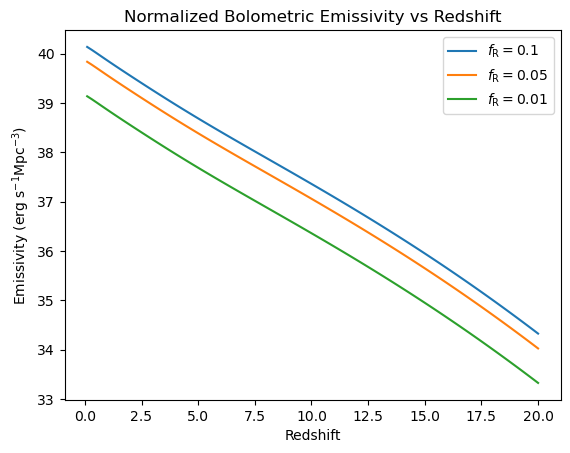

In [104]:
plt.plot(z_range, np.log10(Norm_EmPerEn_integral), label = r'$f_\text{R}=0.1$')
plt.plot(z_range, np.log10(Norm_EmPerEn_integral_2), label = r'$f_\text{R}=0.05$')
plt.plot(z_range, np.log10(Norm_EmPerEn_integral_3), label = r'$f_\text{R}=0.01$')
plt.xlabel(r'Redshift')
plt.ylabel(r'Emissivity (erg s$^{-1}$Mpc$^{-3}$)')
plt.title(r'Normalized Bolometric Emissivity vs Redshift')

plt.legend()

In [105]:
Norm_EmPerEn_vals_2 = np.zeros((len(z_range), len(E_integration_range)))

for i in range(len(z_range)):
    for j in range(len(E_integration_range)):
        Norm_EmPerEn_vals_2[i, j] = accretion_emissivityPerEnergy(E_integration_range[j], z_range[i]) * EmmPerEn_Norm_2[i]

Norm_EmPerEn_vals_3 = np.zeros((len(z_range), len(E_integration_range)))

for i in range(len(z_range)):
    for j in range(len(E_integration_range)):
        Norm_EmPerEn_vals_3[i, j] = accretion_emissivityPerEnergy(E_integration_range[j], z_range[i]) * EmmPerEn_Norm_3[i]

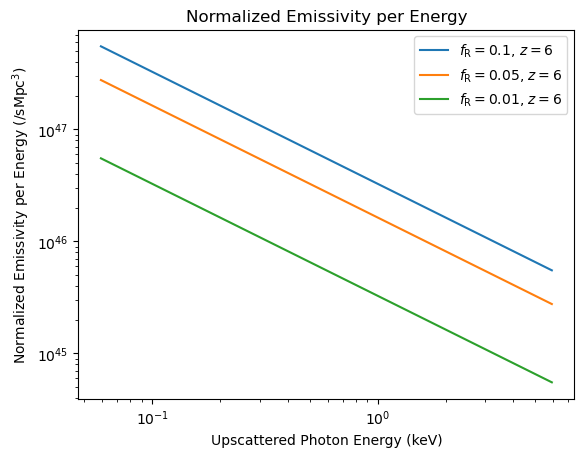

In [107]:
plt.loglog(E_int_range_keV, Norm_EmPerEn_vals[30], label = r'$f_\text{R}=0.1$, $z=6$')
plt.loglog(E_int_range_keV, Norm_EmPerEn_vals_2[30], label = r'$f_\text{R}=0.05$, $z=6$')
plt.loglog(E_int_range_keV, Norm_EmPerEn_vals_3[30], label = r'$f_\text{R}=0.01$, $z=6$')
plt.xlabel(r'Upscattered Photon Energy (keV)')
plt.ylabel(r'Normalized Emissivity per Energy (/sMpc$^3$)')
plt.title(r'Normalized Emissivity per Energy')
plt.legend()

/tmp/ipykernel_5966/2276681981.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.plot(z_range, np.log10(LMXB_Em_vals), label = r'LMXB', ls = '--')


Text(0.5, 1.0, 'Bolometric Emissivity vs Redshift')

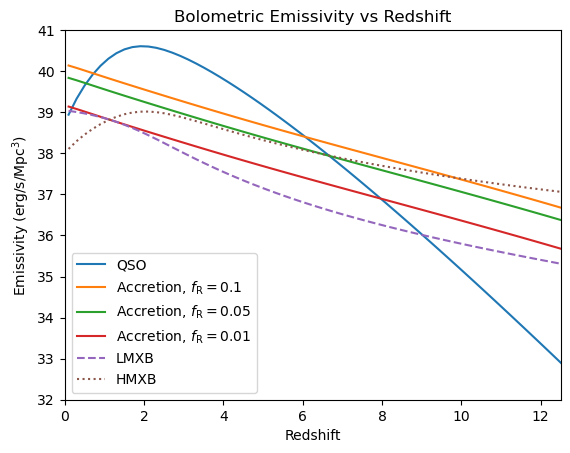

In [110]:
plt.plot(z_range, np.log10(QSO_Bol_Em_vals), label = r'QSO')
plt.plot(z_range, np.log10(Norm_EmPerEn_integral), label = r'Accretion, $f_\text{R}=0.1$')
plt.plot(z_range, np.log10(Norm_EmPerEn_integral_2), label = r'Accretion, $f_\text{R}=0.05$')
plt.plot(z_range, np.log10(Norm_EmPerEn_integral_3), label = r'Accretion, $f_\text{R}=0.01$')
plt.plot(z_range, np.log10(LMXB_Em_vals), label = r'LMXB', ls = '--')
plt.plot(z_range, np.log10(HMXB_Em_vals), label = r'HMXB', ls = ':')
plt.ylim(32, 41)
plt.xlim(0, 12.5)
plt.legend()

plt.xlabel(r'Redshift')
plt.ylabel(r'Emissivity (erg/s/Mpc$^3$)')
plt.title(r'Bolometric Emissivity vs Redshift')

Text(0.5, 1.0, 'Emissivity per Energy at $z=6$')

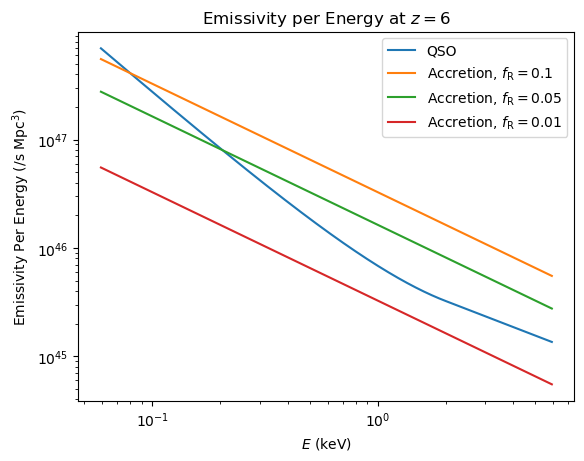

In [111]:
plt.loglog(E_int_range_keV, QSO_EmPerE_arr[30], label = r'QSO')
plt.loglog(E_int_range_keV, Norm_EmPerEn_vals[30], label = r'Accretion, $f_\text{R}=0.1$')
plt.loglog(E_int_range_keV, Norm_EmPerEn_vals_2[30], label = r'Accretion, $f_\text{R}=0.05$')
plt.loglog(E_int_range_keV, Norm_EmPerEn_vals_3[30], label = r'Accretion, $f_\text{R}=0.01$')
plt.xlabel(r'$E$ (keV)')
plt.ylabel(r'Emissivity Per Energy (/s Mpc$^3$)')
plt.legend()
plt.title(r'Emissivity per Energy at $z=6$')